# Nonlinear Least Squares Benchmark Analysis

In [1]:
from experiments import *
from visualization import *

import inspect
from optimization_project import problems as problems_module

In [2]:
problems = [
    cls() for name, cls in inspect.getmembers(problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

## Overall Results

In [3]:
df_results = benchmark_methods(problems)

Running problem: BoxBOD
Running problem: Chwirut1


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))


Running problem: DanWood
Running problem: Eckerle4
Running problem: MGH17


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


Running problem: Roszman1
Running problem: Thurber


In [4]:
df_results

,problem,difficulty,classification_model,structure,method,start_name,success,iterations,final_rss,parameter_error,relative_parameter_error,rss_error,relative_rss_error,gradient_norm
0,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,25,1168.008877,1.341833e-07,6.275818e-10,4.444769e-08,3.805424e-11,7.440162e-05
1,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 1,True,24,1168.008879,9.859595e-04,4.611379e-06,2.701489e-06,2.312901e-09,2.401449e-01
2,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,12,1168.008877,1.151568e-07,5.385940e-10,4.444769e-08,3.805424e-11,8.426021e-05
3,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 2,True,8,1168.008884,1.660473e-03,7.766111e-06,7.757208e-06,6.641395e-09,4.053286e-01
4,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,8,34.378592,2.073276e-01,1.087375e+00,2.350099e+03,9.855823e-01,2.237629e-04
5,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 1,True,11,34.378592,2.073280e-01,1.087377e+00,2.350099e+03,9.855823e-01,4.038586e-02
6,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,9,34.378592,2.073276e-01,1.087375e+00,2.350099e+03,9.855823e-01,3.403118e-04
7,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 2,True,13,34.378592,2.073276e-01,1.087375e+00,2.350099e+03,9.855823e-01,8.337589e-04
8,DanWood,Lower,Miscellaneous,Overdetermined,ModifiedGN,NIST Start 1,True,10,0.004317,4.424289e-11,1.123993e-11,8.945969e-15,2.072117e-12,1.114529e-11
9,DanWood,Lower,Miscellaneous,Overdetermined,LM-lm,NIST Start 1,True,6,0.004317,2.480603e-08,6.301983e-09,8.687495e-15,2.012248e-12,9.487881e-09


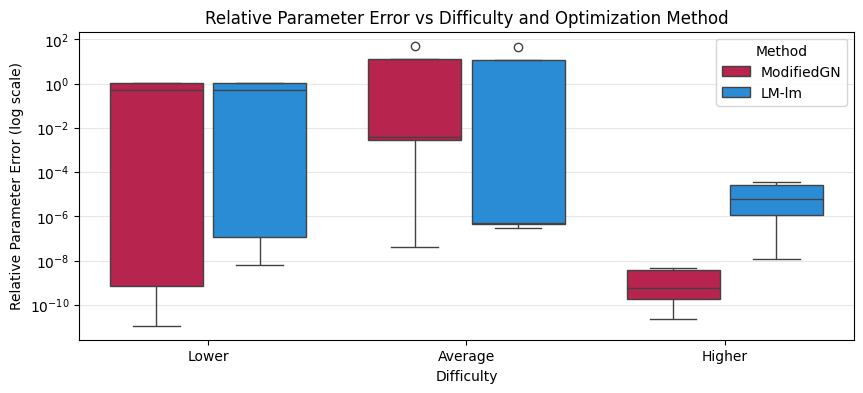

In [5]:
plot_boxplot(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

---

In [6]:
problems_2d = [p for p in problems if p.n == 2]

C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in multiply
  return b[0] * (1 - np.exp(-b[1] * x))
c:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\notebooks\visualization.py:121: RuntimeWarning: overflow encountered in square
  Z[i, j] = np.sum(problem.F(p)**2)


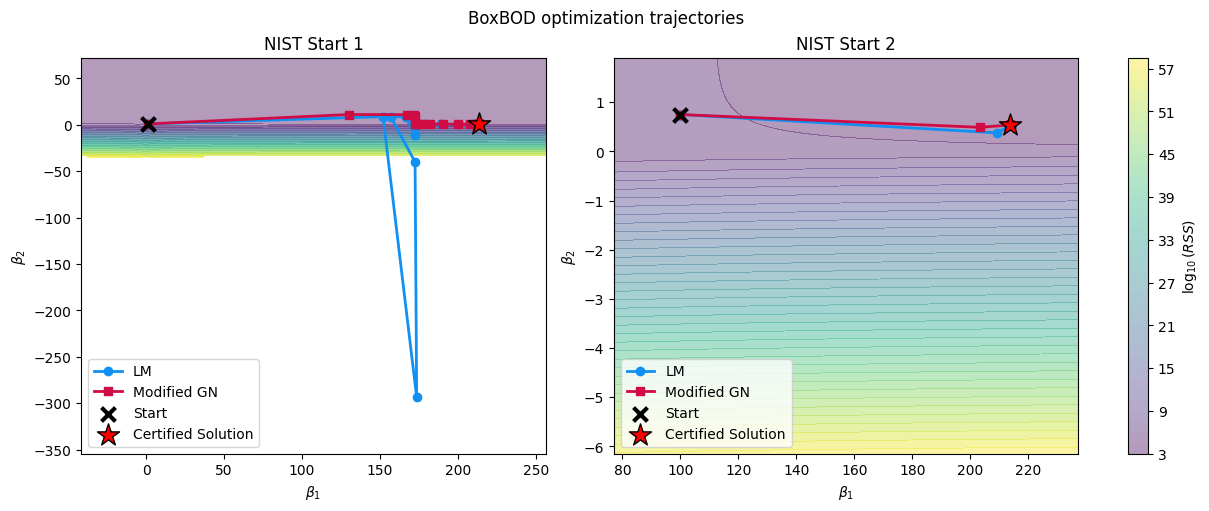

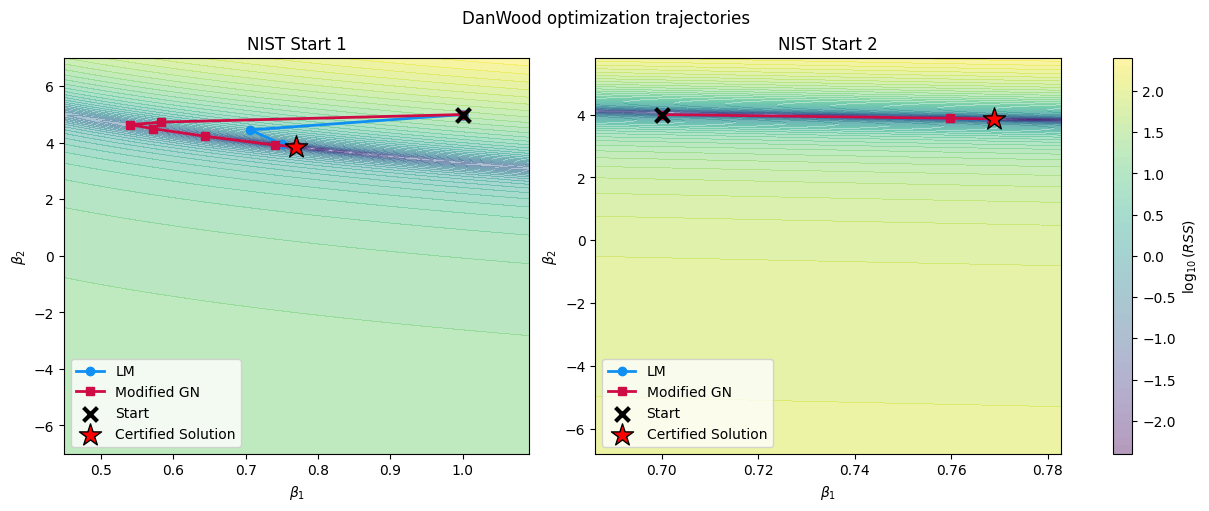

In [7]:
trajectory_data = generate_trajectory_data(
    problems_2d
)

for problem_data in trajectory_data:

    plot_optimizer_paths(problem_data, y_limit=(-5, 5))

---

In [11]:
def compare_methods_convergence(problems):

    for problem in problems:

        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5), constrained_layout=True)

        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # ---------------------------------------------------
            # 1. Modified GN (Secular)
            # ---------------------------------------------------

            result_mgn = modified_gauss_newton(problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="secular"
            )

            # TO BE DELETED
            # ---------------------------------------------------
            # 2. Modified GN (Bisection)
            # ---------------------------------------------------

            result_bis = modified_gauss_newton(
                problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="bisection"
            )

            # ---------------------------------------------------
            # 3. SciPy LM (history safe extraction)
            # ---------------------------------------------------

            lm_res = run_lm_with_history(problem, x0)
            hist_sp = [
                np.sum(problem.F(x) ** 2)
                for x in lm_res.x_history
            ]


            ax.semilogy(result_mgn.rss_history, label="Modified GN (Secular)", linewidth=2,
                        color=method_palette["ModifiedGN"])

            ax.semilogy(result_bis.rss_history, label="Modified GN (Bisection)", linestyle="--",
                        color="black", alpha=0.7)

            ax.semilogy(hist_sp, label="SciPy LM", linewidth=2, 
                        color=method_palette["LM-lm"], alpha=0.9)

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid(True, which="both", ls="-", alpha=0.4)
            ax.legend()

        fig.suptitle(
            f"{problem.name} – convergence comparison",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()


=== BoxBOD ===


C:\Users\olenk\AppData\Local\Temp\ipykernel_62148\1546752592.py:51: RuntimeWarning: overflow encountered in square
  np.sum(problem.F(x) ** 2)
C:\Users\olenk\AppData\Local\Temp\ipykernel_62148\1546752592.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


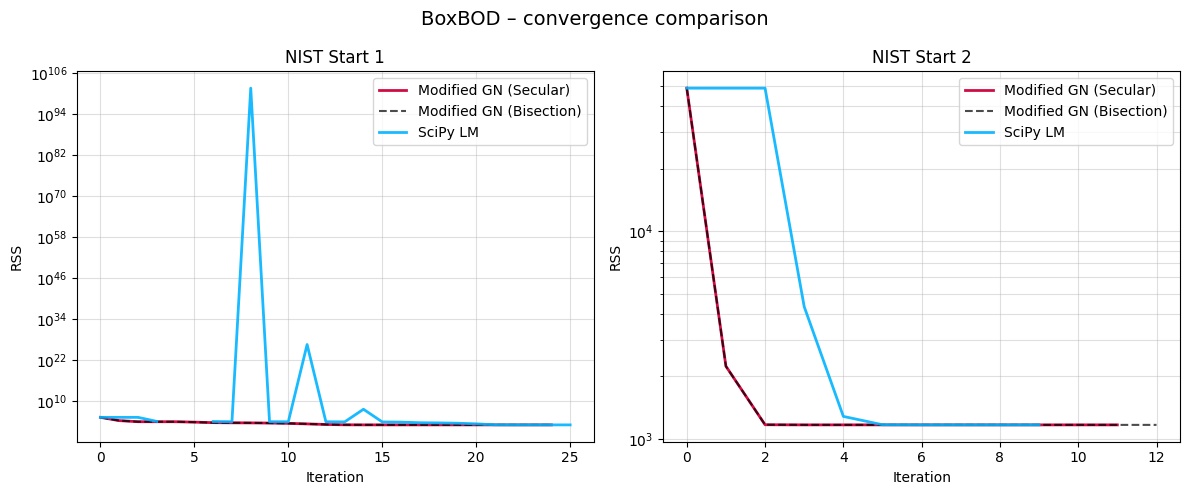


=== Chwirut1 ===


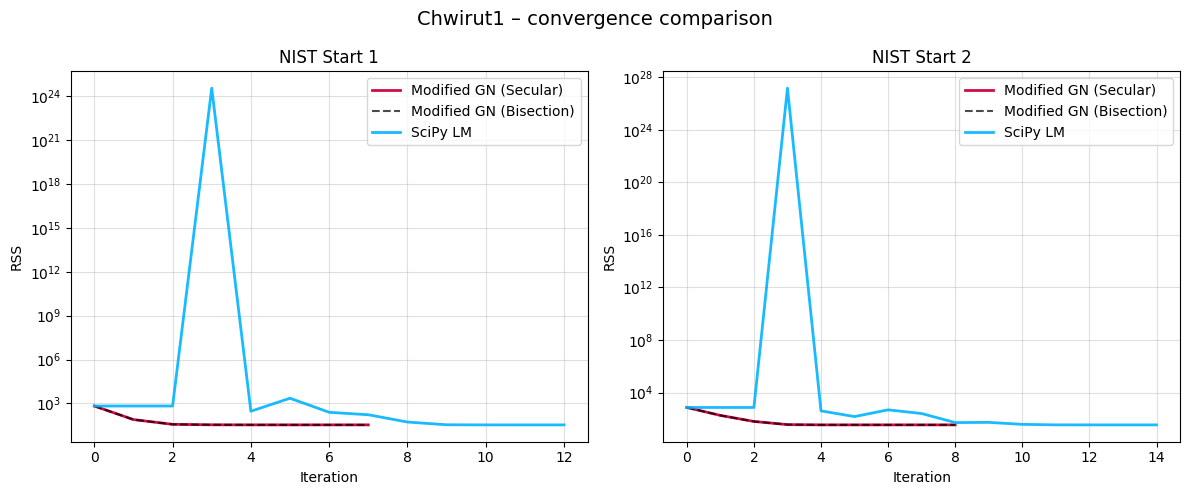


=== DanWood ===


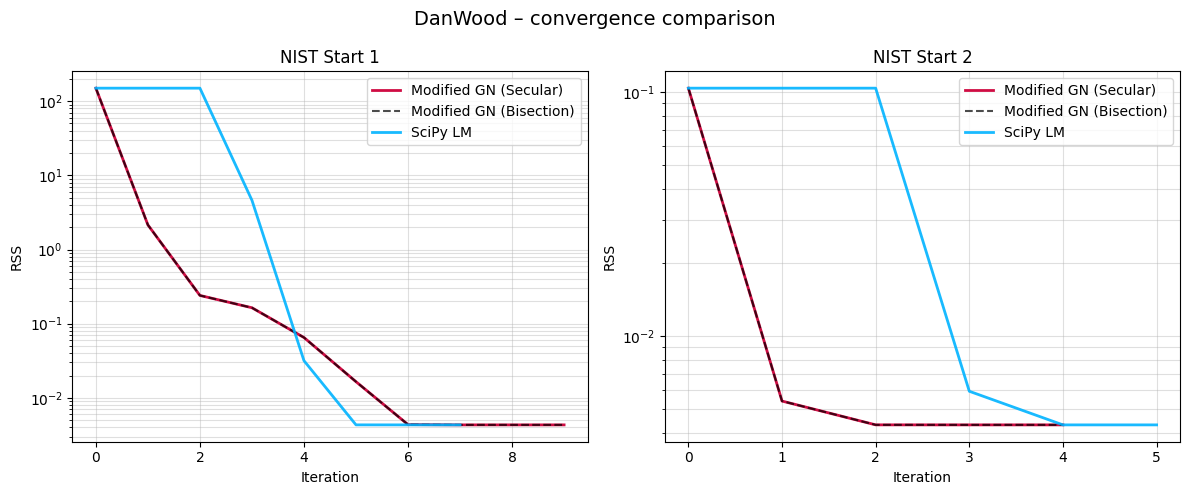


=== Eckerle4 ===


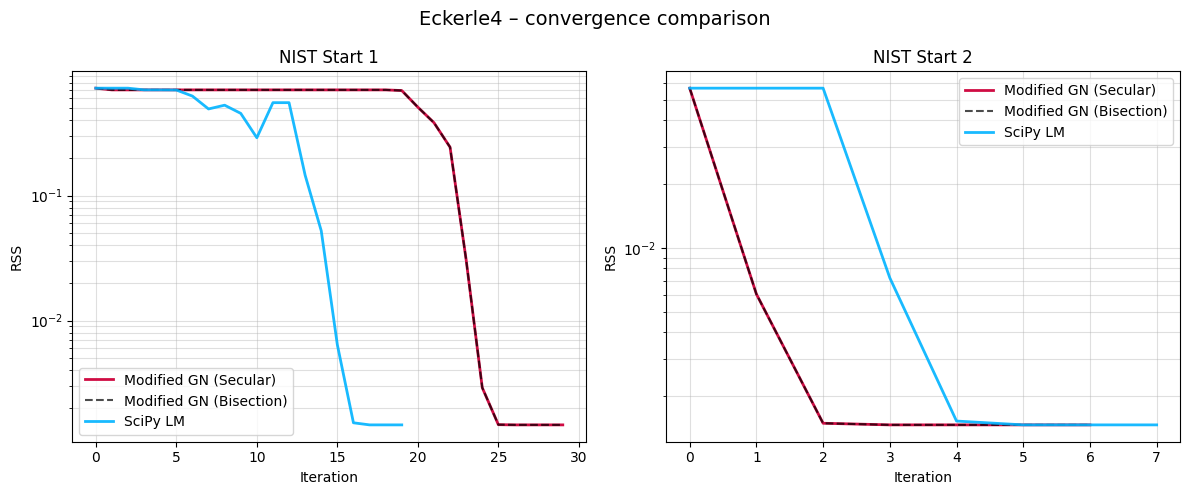


=== MGH17 ===


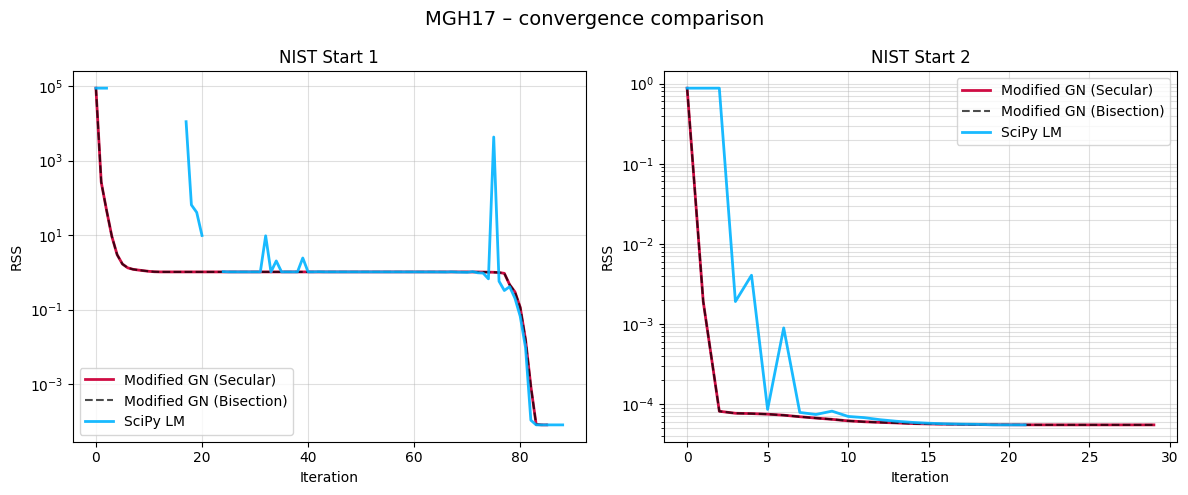


=== Roszman1 ===


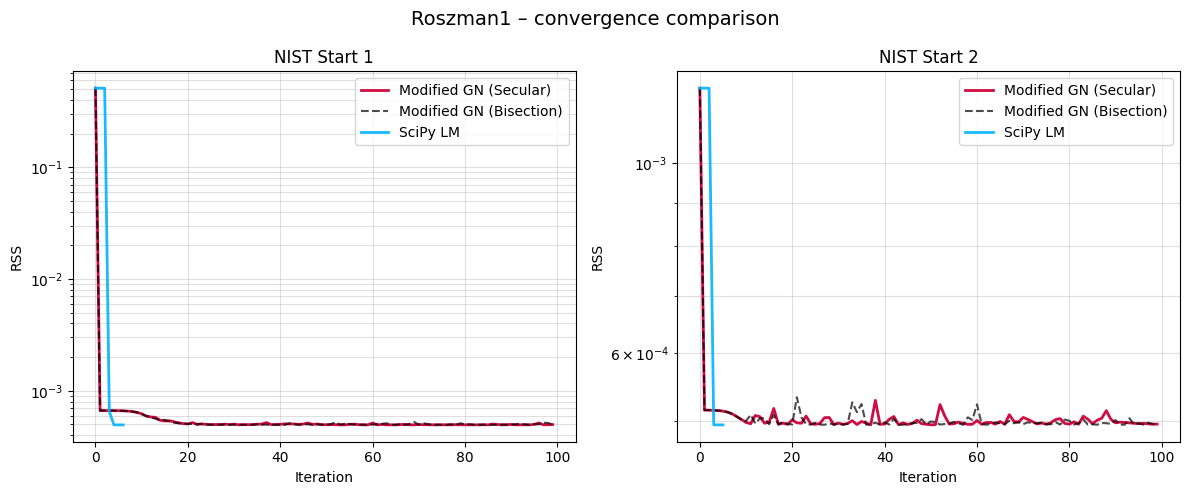


=== Thurber ===


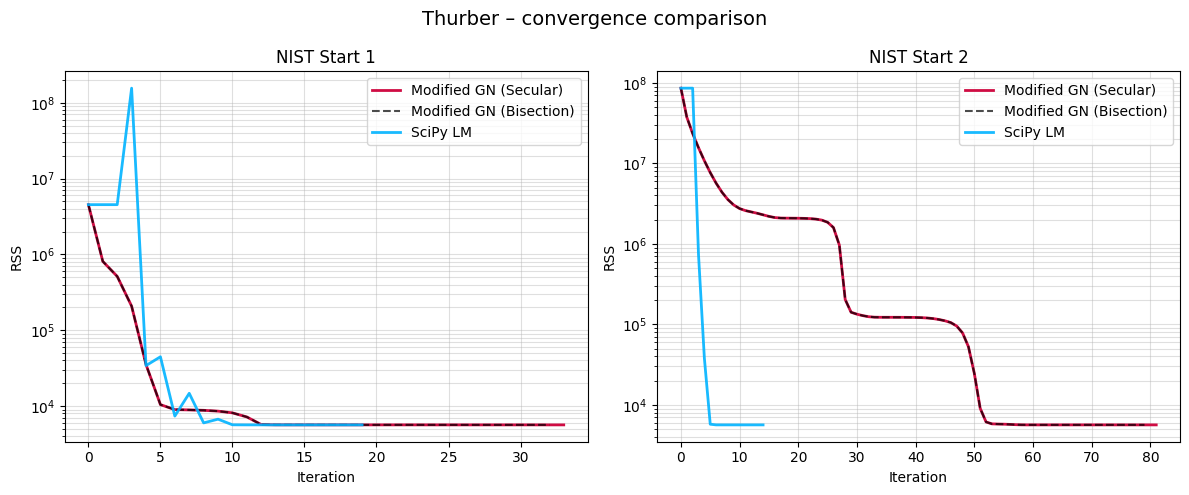

In [12]:
compare_methods_convergence(problems)